# ENTEGA FINAL: PREDICCION DE CHURN Y VALOR DE CLIENTE EN UN E-COMMERCE

## 1. ABSTRACTO

### Motivación
En la industria del e e-commerce, retener a un cliente existente es significativamente mas rentable que adquirir uno nuevo. Sin embargo, muchas empresas no cuentan con herramientas predictivas para anticipar que clientes estan en riesgo de abandonar la plataforma (*churn*) ni para estimar cuanto valor economico representa cada cliente a futuro.

En este trabajo se utilizo el dataset "Online Retail II", que contiene transacciones de una empresa de venta minorista online del Reino Unido entre Diciembre 2009 y Diciembre 2011.
A partir de los datos de esas transacciones, se construyeron perfiles de comportamiento por cliente usando el **RFM (Recency, Frequency, Monetary)** y buscamos entrenar modelos de Machine Learning para resolver dos problemas:

1. **Clasificacion (problema principal):** ¿Este cliente va a hacer churn (dejar de comprar) en el próximo periodo?
2. **Regresión (problema secundario):** ¿Cuánto dinero gastará este cliente en el próximo periodo?

Se define *churn* como un cliente que compró durante el primer año del dataset (2009-2010) pero que no realizó ninguna compra en los ultimos 90 dias  del periodo disponible (2011)

### Audiencia
- Equipos de Marketing y Vebtas que buscan segmentar clientes en riesgo para campañas de retención anticipando la perdida de clientes y que esten interesados en comprender el comportamiento de sus clientes.
- Equipos de negocio y producto interesados en priorizar recursos segun el valor potencial de cada cliente.
- Mandos Medios y Altos que buscan maximizar ingresos y minizar perdidas de clientes y ventas.

## 2. PREGUNTAS E HIPOTESIS A RESOLVER

1. ¿Qué clientes tienen alta probabilidad de hacer churn en los próximos 90 dias? ¿Y en los próximos 180 dias?
2. ¿Cuánto dinero va a gastar un cliente activo en el próximo periodo?
3. ¿Qué caracteristicas tienen los clientes más valiosos?
4. ¿el tiempo desde la última compra influye en el abandono?


### Hipotesis de trabajo
1. Cliente con baja frecuencia de compra tienen mayor probabilidad de churn.
2. Cliente con con mayor tiempo sin comprar tienen mayor probabilidad de churn.
3. El valor monetario histórico es el predictor mas importante del gasto futuro.
4. Los clientes con menor gasto tienen menor fidelidad.

In [1]:
# INSTALACION

!pip install ucimlrepo xgboost shap -q

# CARGA DE LIBRERIAS
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
import datetime as dt

In [2]:
# CARGA DE DATASET
path = kagglehub.dataset_download("mashlyn/online-retail-ii-uci")

df= pd.read_csv(os.path.join(path, 'online_retail_II.csv'), encoding='latin-1')

print(f"✅ Dataset cargado exitosamente")
print(f"   Filas: {df.shape[0]:,}")
print(f"   Columnas: {df.shape[1]}")
df.head()

Using Colab cache for faster access to the 'online-retail-ii-uci' dataset.
✅ Dataset cargado exitosamente
   Filas: 1,067,371
   Columnas: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# VISTA GENERAL

print("── Tipos de datos ──")
print(df.dtypes)
print(f"\n── Valores nulos ──")
print(df.isnull().sum())
print(f"\n── Estadísticas descriptivas ──")
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

── Tipos de datos ──
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

── Valores nulos ──
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

── Estadísticas descriptivas ──


,Quantity,Price,Customer ID
count,1067371.00,1067371.00,824364.00
mean,9.94,4.65,15324.64
std,172.71,123.55,1697.46
min,-80995.00,-53594.36,12346.00
25%,1.00,1.25,13975.00
50%,3.00,2.10,15255.00
75%,10.00,4.15,16797.00
max,80995.00,38970.00,18287.00


Se puede observar que el tipo de dato de fecha esta mal definido, como tambien muchos nulos en Customer ID y ademas, presencia fuerte de outlier. Y adems valores negativos, que significan devoluciones.

## DESCRIPCIÓN DEL DATASET Y VARIABLES

El dataset **Online Retail II** contiene transacciones de una tienda minorista online del Reino Unido entre diciembre de 2009 y diciembre de 2011.

### Variables originales del dataset

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `Invoice` | String | Número único de factura. Las facturas que comienzan con 'C' corresponden a cancelaciones/devoluciones |
| `StockCode` | String | Código único de producto |
| `Description` | String | Nombre o descripción del producto |
| `Quantity` | Entero | Cantidad de unidades vendidas por transacción. Valores negativos indican devoluciones |
| `InvoiceDate` | Datetime | Fecha y hora de la transacción |
| `Price` | Float | Precio unitario del producto en libras esterlinas (£) |
| `Customer ID` | Float | Identificador único del cliente. Puede contener valores nulos |
| `Country` | String | País de residencia del cliente |

### Variables construidas (Ingeniería de Atributos)

A partir de los datos transaccionales, se construyeron las siguientes variables de comportamiento por cliente usando el framework **RFM**:

| Variable | Descripción |
|----------|-------------|
| `Recency` | Días transcurridos desde la última compra del cliente hasta la fecha de corte (01/09/2011) |
| `Frequency` | Cantidad de facturas únicas generadas por el cliente en el período de observación |
| `Monetary` | Gasto total del cliente en el período de observación (suma de Quantity × Price) |
| `AvgOrderValue` | Ticket promedio por orden (Monetary / Frequency) |
| `Frequency_log` | Transformación logarítmica de Frequency para reducir la asimetría de la distribución |
| `Monetary_log` | Transformación logarítmica de Monetary para reducir la asimetría de la distribución |
| `UniqueProds` | Cantidad de productos distintos (StockCode únicos) comprados por el cliente |
| `UniqueProds_log` | Transformación logarítmica de UniqueProds |

### Variable target

| Variable | Descripción |
|----------|-------------|
| `churn` | Variable binaria: `1` si el cliente **no realizó compras** en el período de evaluación (sep-dic 2011), `0` si compró al menos una vez |
| `FutureRevenue` | Gasto real del cliente en el período de evaluación (sep-dic 2011). Usada como target en el modelo de regresión |


## ANALISIS EXPLORATORIO DE DATOS

Para explorar la calidad y distribución de los datos.

In [4]:
# COPIA DEL DATASET
df1 = df.copy()

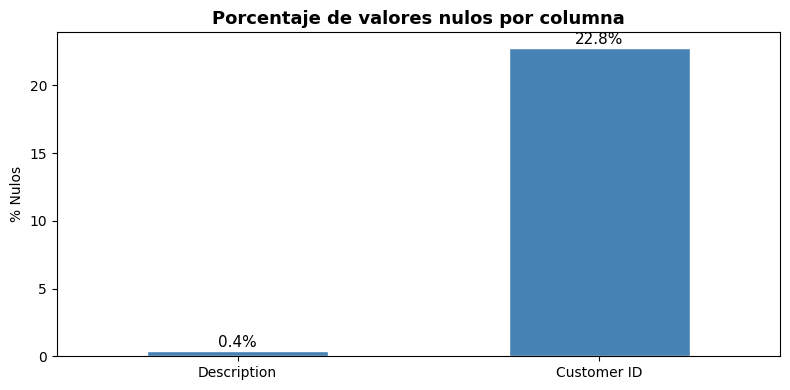

In [5]:
# VALORES NULOS

fig, ax = plt.subplots(figsize=(8, 4))
null_pct = df1.isnull().mean() * 100
null_pct = null_pct[null_pct > 0]
null_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Porcentaje de valores nulos por columna', fontsize=13, fontweight='bold')
ax.set_ylabel('% Nulos')
ax.set_xlabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2, p.get_height() + 0.3),
                ha='center', fontsize=11)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

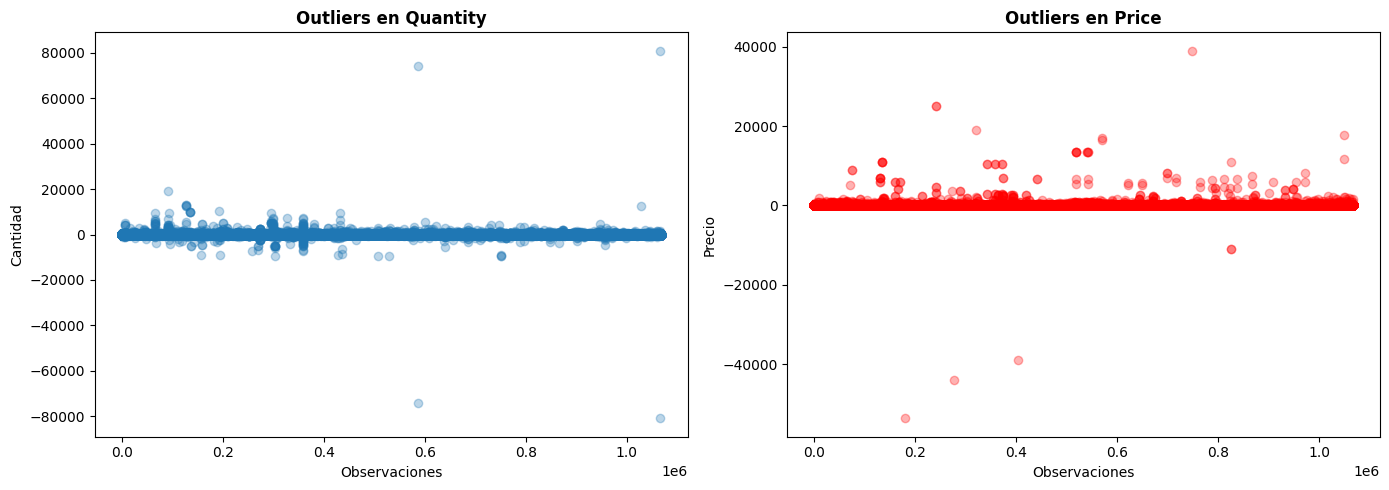

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quantity

axes[0].scatter(range(len(df1)), df1["Quantity"], alpha=0.3)
axes[0].set_title("Outliers en Quantity", fontweight="bold")
axes[0].set_xlabel("Observaciones")
axes[0].set_ylabel("Cantidad")

# Price

axes[1].scatter(range(len(df1)), df1["Price"], alpha=0.3, color="red")
axes[1].set_title("Outliers en Price", fontweight="bold")
axes[1].set_xlabel("Observaciones")
axes[1].set_ylabel("Precio")
plt.tight_layout()
plt.show()

Despues de analizar los graficos, se tomo la decision de eliminar valores nulos en "Customer ID", como tambien las transacciones con cantidades ngativas y facturas de cancelacion, ya que representan devoluciones y no compras reales, lo cual podria distorcionar el analisis del comportamiento del cliente. Se observa una alta concentración de valores bajos y una pequeña cantidad de observaciones con valores significativamente elevados, lo que confirma la existencia de outliers.

In [7]:
# LIMPIEZA

# ELIMINAR NULOS EN CUSTOMER ID

df1 = df.dropna(subset=["Customer ID"])

# ELIMINAR DEVOLUCIONES POR CANTIDAD

df1 = df1[df1["Quantity"] > 0]

# ELIMINAR DEVOLUCIONES POR INVOICE
df1 = df1[~df1["Invoice"].str.startswith("C")]

print("Filas restantes:", df1.shape)

Filas restantes: (805620, 8)


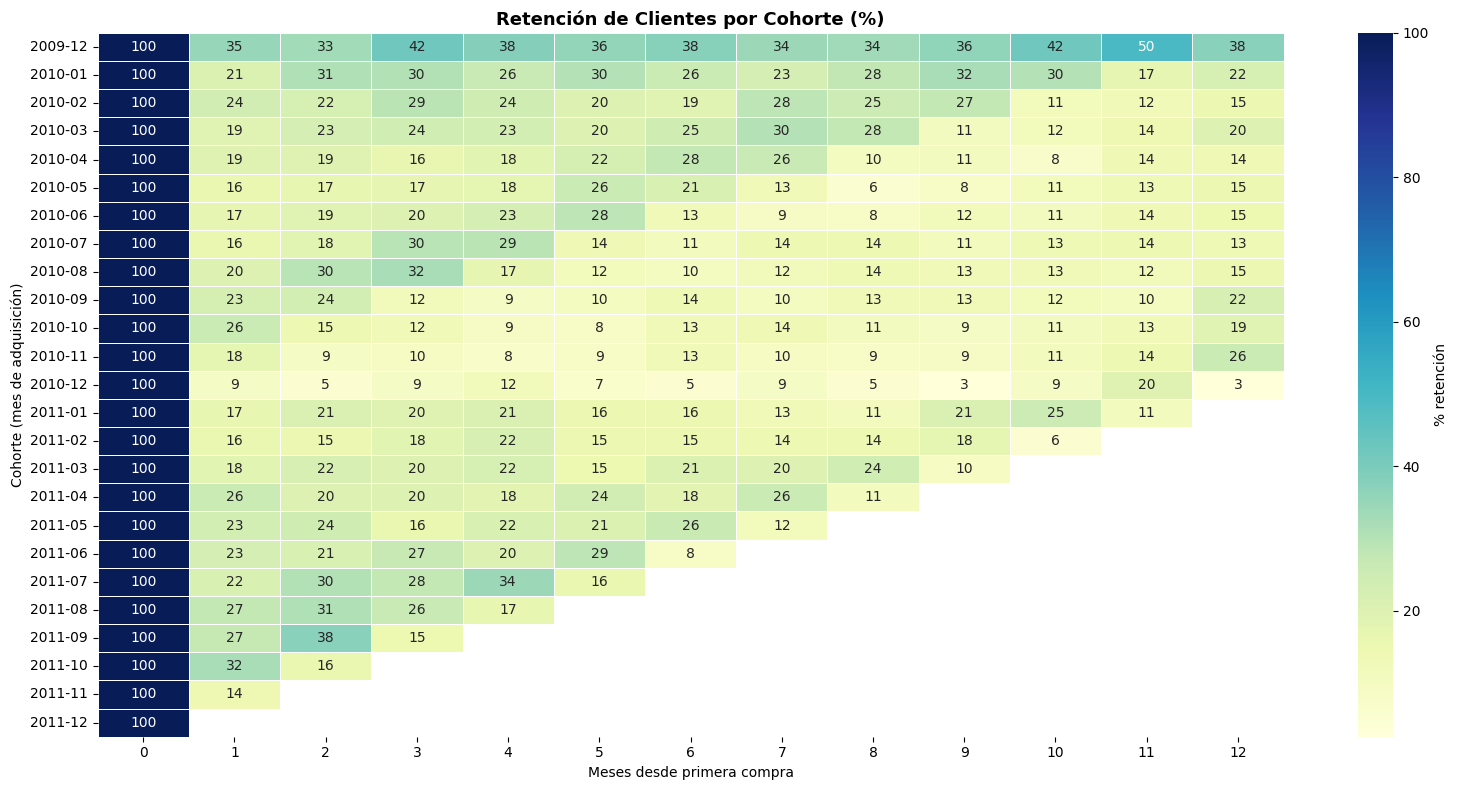

In [8]:
# ANÁLISIS DE COHORTES

# Mes de primera compra por cliente

df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'])
df1['InvoiceMonth'] = df1['InvoiceDate'].dt.to_period('M')

cohorte = df1.groupby('Customer ID')['InvoiceMonth'].min().reset_index()
cohorte.columns = ['Customer ID', 'CohortMonth']

df1 = df1.merge(cohorte, on='Customer ID')

df1['CohortIndex'] = (
    (df1['InvoiceMonth'].dt.year - df1['CohortMonth'].dt.year) * 12 +
    (df1['InvoiceMonth'].dt.month - df1['CohortMonth'].dt.month)
)

# Tabla de retención

cohort_data = df1.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')
cohort_pct = cohort_pivot.divide(cohort_pivot[0], axis=0).round(3) * 100

# Heatmap

plt.figure(figsize=(16, 8))
sns.heatmap(cohort_pct.iloc[:, :13], annot=True, fmt='.0f',
            cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': '% retención'})
plt.title('Retención de Clientes por Cohorte (%)', fontsize=13, fontweight='bold')
plt.xlabel('Meses desde primera compra')
plt.ylabel('Cohorte (mes de adquisición)')
plt.tight_layout()
plt.show()

### Conclusiones del análisis de cohortes

- La retención cae drásticamente en el **primer mes**: la mayoría de las cohortes pierde entre el 70% y el 85% de sus clientes en el mes 1.
- A partir del mes 2, la retención se estabiliza en niveles bajos (entre el 10% y el 30%), lo que indica que los clientes que logran volver una segunda vez tienden a quedarse.
- La cohorte de **Diciembre 2009** muestra la mejor retención sostenida en el tiempo, posiblemente por ser clientes más antiguos y fieles.
- Este patrón justifica el uso de ML para **anticipar el churn temprano**, especialmente en los primeros meses de vida del cliente.

In [9]:
# CONVERSION DE FECHAS

df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'])

print(f"Rango de fechas: {df1['InvoiceDate'].min().date()} → {df1['InvoiceDate'].max().date()}")
print(f"Clientes únicos (con ID): {df1['Customer ID'].nunique():,}")
print(f"Facturas únicas: {df1['Invoice'].nunique():,}")
print(f"Países únicos: {df1['Country'].nunique()}")

Rango de fechas: 2009-12-01 → 2011-12-09
Clientes únicos (con ID): 5,881
Facturas únicas: 36,975
Países únicos: 41


## ANALISIS UNIVARIADO

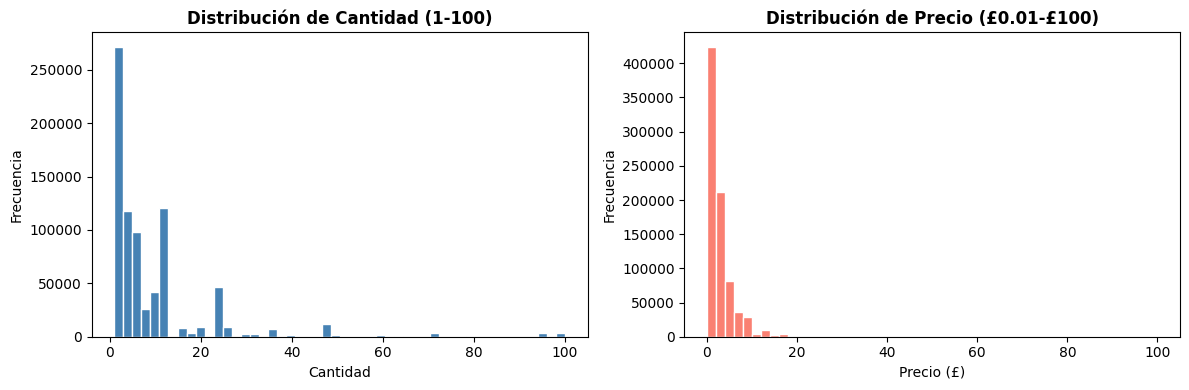

In [10]:
# CANTIDAD Y PRECIO
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Filtramos outliers extremos solo para visualización
q_pos = df1[df1['Quantity'].between(1, 100)]['Quantity']
p_pos = df1[df1['Price'].between(0.01, 100)]['Price']

axes[0].hist(q_pos, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Cantidad (1-100)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cantidad')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(p_pos, bins=50, color='salmon', edgecolor='white')
axes[1].set_title('Distribución de Precio (£0.01-£100)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Precio (£)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Para una mejor interpretación visual, se limitaron los rangos de las variables Quantity (Cantidad) y Price (Precio), excluyendo valores extremos.

Por lo que se observa valores concetrados alrededor del cero en ambos graficos.



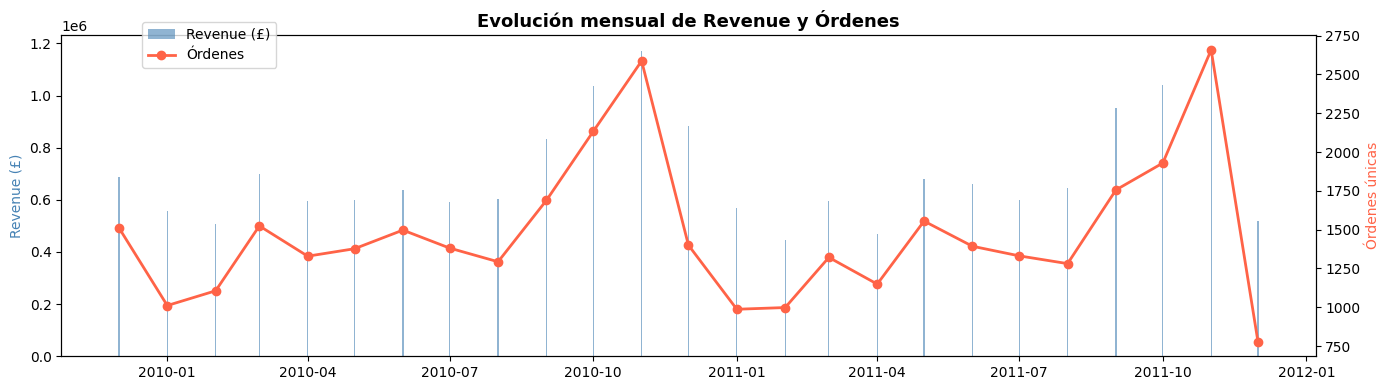

In [11]:
# VENTAS MENSUALES

df1['YearMonth'] = df1['InvoiceDate'].dt.to_period('M')
monthly = df1[df1['Quantity'] > 0].groupby('YearMonth').agg(
    Revenue=('Price', lambda x: (x * df1.loc[x.index, 'Quantity']).sum()),
    Orders=('Invoice', 'nunique')
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(14, 4))
ax2 = ax1.twinx()
ax1.bar(monthly['YearMonth'], monthly['Revenue'], color='steelblue', alpha=0.6, label='Revenue (£)')
ax2.plot(monthly['YearMonth'], monthly['Orders'], color='tomato', marker='o', linewidth=2, label='Órdenes')
ax1.set_title('Evolución mensual de Revenue y Órdenes', fontsize=13, fontweight='bold')
ax1.set_ylabel('Revenue (£)', color='steelblue')
ax2.set_ylabel('Órdenes únicas', color='tomato')
ax1.set_xlabel('')
plt.xticks(rotation=45, ha='right')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

El Revenue representa los ingresos totales generados por las ventas, calculado como el producto entre la cantidad vendida y el precio unitario. Se analiza su evolucion mensual para identicar patrones de comportamiento en el negocio.

Se observa que la cantidad de órdenes acompaña la evolución del revenue, mostrando una relación directa entre ambas variables. Se identifican picos en noviembre de 2010 y diciembre de 2011, mientras que los valores más bajos se registran en enero y febrero de 2011, así como en enero de 2010. Esto sugiere un posible patrón estacional, con mayor actividad hacia fin de año y menor actividad en los primeros meses.

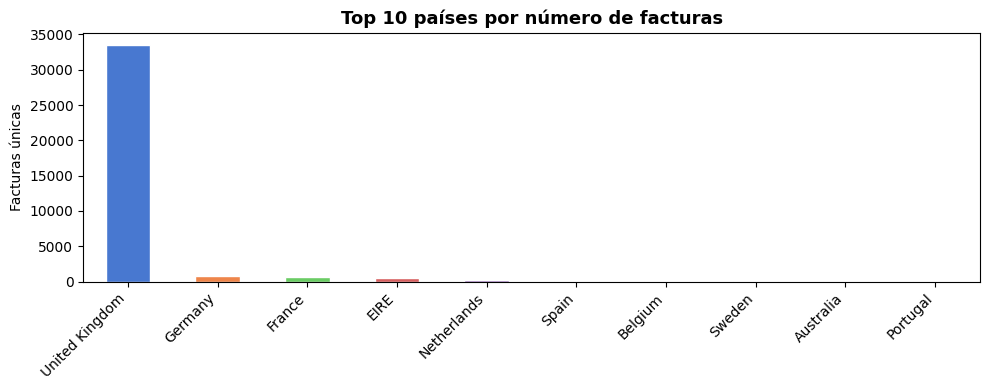

In [12]:
# TOP DE PAISES

top_countries = df1.groupby('Country')['Invoice'].nunique().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 4))
top_countries.plot(kind='bar', ax=ax, color=sns.color_palette('muted', 10), edgecolor='white')
ax.set_title('Top 10 países por número de facturas', fontsize=13, fontweight='bold')
ax.set_ylabel('Facturas únicas')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Se observa que el Reino Unido concentra la gran mayoría de las facturas, evidenciando una fuerte concentración geográfica del negocio. En menor medida, le siguen países como Francia, Alemania e Irlanda (EIRE), aunque con una participación significativamente inferior.


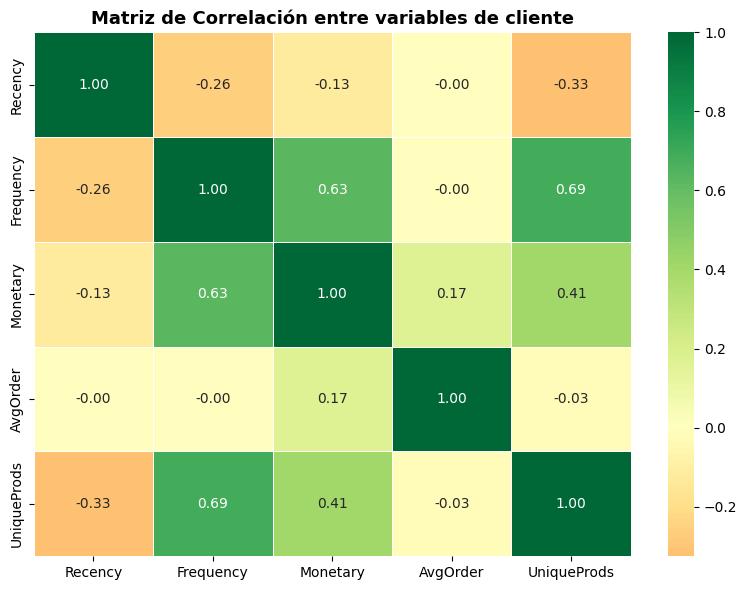

In [13]:
# MATRIZ DE CORRELACIONES
df1['Revenue'] = df1['Quantity'] * df1['Price']

corr_df = df1.groupby('Customer ID').agg(
    Recency    = ('InvoiceDate', lambda x: (df1['InvoiceDate'].max() - x.max()).days),
    Frequency  = ('Invoice', 'nunique'),
    Monetary   = ('Revenue', 'sum'),
    AvgOrder   = ('Revenue', 'mean'),
    UniqueProds= ('StockCode', 'nunique')
).reset_index()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df.drop(columns='Customer ID').corr(),
            annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlación entre variables de cliente', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Conclusiones de la matriz de correlación

- **Frequency y Monetary (0.63):** los clientes que compran más seguido también gastan más en total, lo cual es esperable.
- **Frequency y UniqueProds (0.69):** los clientes frecuentes también compran mayor variedad de productos.
- **Recency y Frequency (-0.26):** a mayor tiempo sin comprar, menor frecuencia histórica — confirma que la recencia es un buen indicador de abandono.
- **AvgOrder** no correlaciona fuerte con ninguna variable, lo que indica que el ticket promedio es independiente del comportamiento de compra general.

# INGENIERIA DE ATRIBUTOS

A partir de los datos transaccionales crudos construimos variables de comportamiento
por cliente. Se aplican transformaciones logarítmicas en variables con alta asimetría
para mejorar el rendimiento de los modelos.

In [14]:
# INGENIERÍA DE ATRIBUTOS CON SEPARACIÓN TEMPORAL
# Período de observación: para construir features (RFM)
# Período de evaluación: para definir el target (churn)

df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'])

fecha_corte = pd.Timestamp('2011-09-01')

df_obs  = df1[df1['InvoiceDate'] < fecha_corte]   # features
df_eval = df1[df1['InvoiceDate'] >= fecha_corte]  # target

print(f"Período de observación: {df_obs['InvoiceDate'].min().date()} → {df_obs['InvoiceDate'].max().date()}")
print(f"Período de evaluación:  {df_eval['InvoiceDate'].min().date()} → {df_eval['InvoiceDate'].max().date()}")
print(f"Clientes en observación: {df_obs['Customer ID'].nunique():,}")
print(f"Clientes en evaluación:  {df_eval['Customer ID'].nunique():,}")

Período de observación: 2009-12-01 → 2011-08-31
Período de evaluación:  2011-09-01 → 2011-12-09
Clientes en observación: 5,251
Clientes en evaluación:  2,974


In [15]:
# CONSTRUCCIÓN DE FEATURES (período de observación)

df_obs["TotalPrice"] = df_obs["Quantity"] * df_obs["Price"]

rfm = df_obs.groupby("Customer ID").agg(
    Recency   = ("InvoiceDate", lambda x: (fecha_corte - x.max()).days),
    Frequency = ("Invoice",     "nunique"),
    Monetary  = ("TotalPrice",  "sum")
).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# Features adicionales

rfm["AvgOrderValue"]  = rfm["Monetary"] / (rfm["Frequency"] + 1)
rfm["Frequency_log"]  = np.log1p(rfm["Frequency"])
rfm["Monetary_log"]   = np.log1p(rfm["Monetary"])

# UniqueProds del período de observación

unique_prods = df_obs.groupby("Customer ID")["StockCode"].nunique().reset_index()
unique_prods.columns = ["CustomerID", "UniqueProds"]
rfm = rfm.merge(unique_prods, on="CustomerID", how="left")
rfm["UniqueProds_log"] = np.log1p(rfm["UniqueProds"])

# TARGET: churn = no compró en el período de evaluación

clientes_eval = set(df_eval["Customer ID"].unique())
rfm["churn"] = rfm["CustomerID"].apply(lambda x: 0 if x in clientes_eval else 1)

print(f"Clientes en RFM: {len(rfm):,}")
print(f"\nDistribución de Churn:")
print(rfm["churn"].value_counts())
print(rfm["churn"].value_counts(normalize=True).round(3))

Clientes en RFM: 5,251

Distribución de Churn:
churn
1    2907
0    2344
Name: count, dtype: int64
churn
1   0.55
0   0.45
Name: proportion, dtype: float64


## ANALISIS BIVARIADO

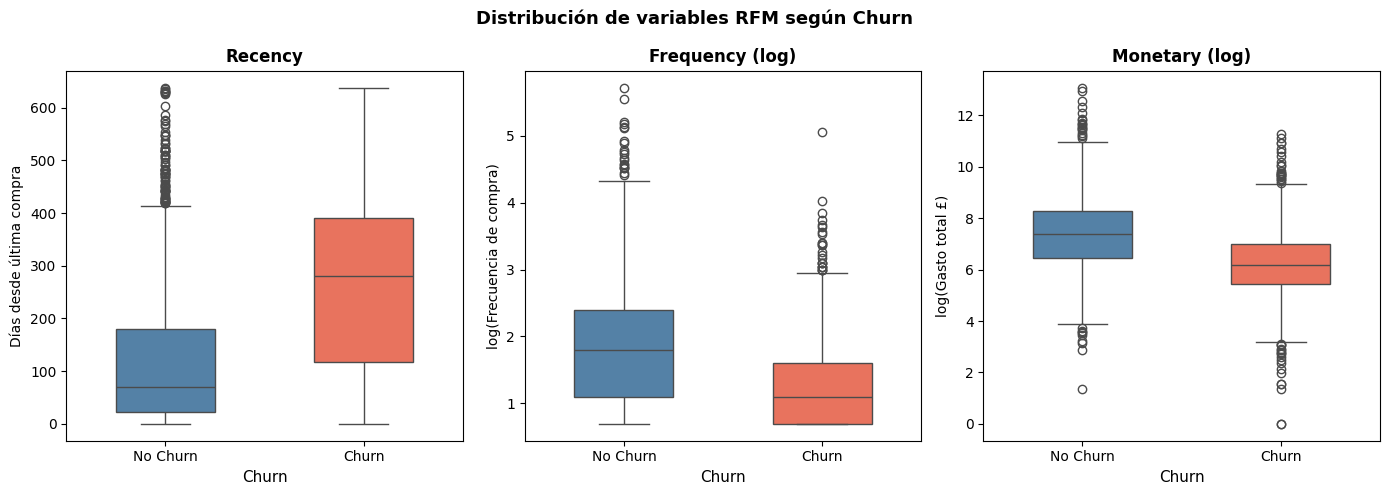

In [16]:
# ANÁLISIS BIVARIADO — RFM vs CHURN

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

variables = [
    ('Recency',       'Recency',        'Días desde última compra'),
    ('Frequency_log', 'Frequency (log)', 'log(Frecuencia de compra)'),
    ('Monetary_log',  'Monetary (log)',  'log(Gasto total £)'),
]

for ax, (col, titulo, ylabel) in zip(axes, variables):
    sns.boxplot(x='churn', y=col, data=rfm, ax=ax,
                palette=['steelblue', 'tomato'],
                width=0.5)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Churn', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xticklabels(['No Churn', 'Churn'])

plt.suptitle('Distribución de variables RFM según Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Hay diferencia entre los grupos, ya que los clientes activos (churn = 0) presentan valores de recency bajos (cercanos a 0), con una mediana baja, lo que indica compras recientes.
Los clientes con churn (churn = 1) muestran valores significativamente más altos, con una mediana cercana a los 400 días y valores que superan los 700 días.

La variable Frequency presenta una alta dispersión y numerosos valores extremos, lo que dificulta su visualización mediante boxplots tradicionales. Para mejorar la interpretación, se aplicaron transformaciones logarítmicas, observándose que los clientes con churn tienden a presentar una menor frecuencia de compra.

En el gráfico de Monetary (log) vs churn, se observa que los clientes activos (churn = False) presentan una mediana ligeramente superior, cercana a 7, junto con una mayor dispersión y presencia de valores extremos. Por otro lado, los clientes con churn (churn = 1) también presentan numerosos outliers, pero con una mediana levemente inferior, alrededor de 6.
Si bien se observa que los clientes activos presentan un mayor nivel de gasto en promedio, la diferencia entre ambos grupos no es tan marcada como en la variable Recency. Esto indica que el gasto por sí solo no es un predictor fuerte de churn.

CONCLUSION: Entre las variables analizadas, Recency se presenta como el mejor predictor del churn, mostrando una clara separación entre clientes activos e inactivos. Frequency y Monetary también aportan información relevante, aunque con menor capacidad discriminante debido a su alta dispersión y presencia de valores extremos.

# ANALISIS MULTIVARIADO

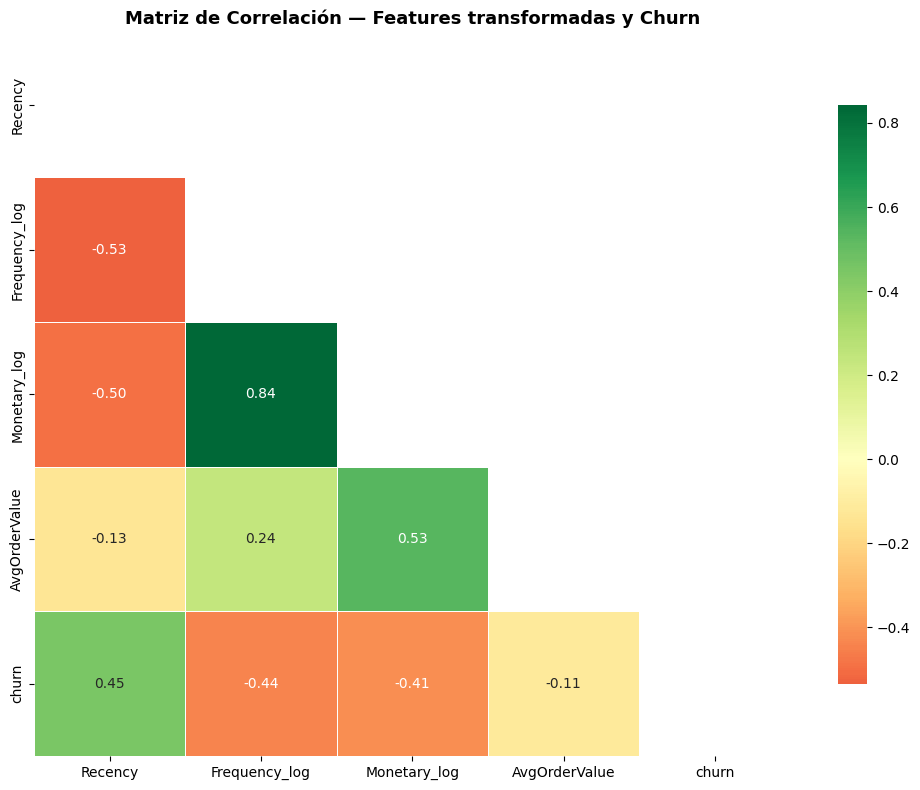

In [17]:
feature_cols = [ 'Recency', 'Frequency_log', 'Monetary_log', 'AvgOrderValue',  'churn']


corr = rfm[feature_cols].corr()

# HEATMAP
fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Matriz de Correlación — Features transformadas y Churn',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### Conclusion de la Matriz de Correlacion

Se observa que Recency es la variable con mayor correlación positiva con churn (0.8), indicando que el tiempo desde la última compra es el principal predictor de abandono. Por otro lado, Frequency y Monetary presentan correlaciones negativas moderadas, lo que sugiere que clientes más activos y con mayor gasto tienden a permanecer. La variable AvgOrderValue muestra una correlación débil, indicando bajo poder explicativo. Además, se observa una alta correlación entre Frequency y Monetary, lo que sugiere redundancia entre ambas variables.

*   Recency, tiempo de la ultima compra
*   Frequency: cantidad de compras que hizo un cliente
*   Monetary: Cuant dinero fasto el cliente en total

Se observa que muchos no compran hace mucho tiempo (recency promedio de 201 dias y maximo de 739 dias), con una frecuencia baja donde la mayoria compra poco y pocos clientes muy activos (mediana de 3 compras), y con outliers muy grandes donde se puede inferir clientes muy valiosos (mam de 608.821)
El análisis RFM muestra una alta variabilidad en el comportamiento de los clientes. Mientras que la mayoría presenta baja frecuencia de compra y gasto moderado, existe un grupo reducido de clientes con valores significativamente altos, lo que indica una distribución altamente sesgada. Asimismo, los valores elevados de recency evidencian la presencia de clientes inactivos.

In [18]:
# FEATURE ADICIONAL: productos únicos comprados por cliente
unique_prods = df1.groupby('Customer ID')['StockCode'].nunique().reset_index()
unique_prods.columns = ['CustomerID', 'UniqueProds']

# Eliminar columnas duplicadas si existen
for col in ['UniqueProds', 'UniqueProds_x', 'UniqueProds_y', 'UniqueProds_log']:
    if col in rfm.columns:
        rfm = rfm.drop(columns=col)

rfm = rfm.merge(unique_prods, on='CustomerID', how='left')
rfm['UniqueProds_log'] = np.log1p(rfm['UniqueProds'])

print("Features disponibles:", rfm.columns.tolist())

Features disponibles: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'Frequency_log', 'Monetary_log', 'churn', 'UniqueProds', 'UniqueProds_log']


In [19]:
# DEFINIR X E Y

feature_cols = [
    'Recency',
    'Frequency_log',
    'Monetary_log',
    'AvgOrderValue',
    'UniqueProds_log'
]

X = rfm[feature_cols]
y = rfm['churn']

print("Shape de X:", X.shape)
print("Distribución de y:\n", y.value_counts(normalize=True).round(3))

Shape de X: (5251, 5)
Distribución de y:
 churn
1   0.55
0   0.45
Name: proportion, dtype: float64


Se seleccionaron 5 variables como features del modelo:
- **Recency:** días desde la última compra
- **Frequency_log:** frecuencia de compra (transformada con log)
- **Monetary_log:** gasto total (transformado con log)
- **AvgOrderValue:** ticket promedio por orden
- **UniqueProds_log:** cantidad de productos únicos comprados (transformada con log)

Ademas, con un churn de 0.51, el Dataset esta practicamente balanceado, por lo que **no** es necesario aplicar tecnicas de balanceo

# MODELADO

In [20]:
# TRAIN/TEST SPLIT 80/20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nDistribución train:")
print(y_train.value_counts(normalize=True).round(3))

Train shape: (4200, 5)
Test shape: (1051, 5)

Distribución train:
churn
1   0.55
0   0.45
Name: proportion, dtype: float64


In [21]:
# VALIDACION CRUZADA - COMPARACION DE MODELOS

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ])
}

print("Validación cruzada (5-fold) — AUC-ROC:\n")
resultados_cv = {}
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc')
    resultados_cv[nombre] = scores
    print(f"  {nombre:25s}  AUC = {scores.mean():.4f} ± {scores.std():.4f}")

Validación cruzada (5-fold) — AUC-ROC:

  Logistic Regression        AUC = 0.8335 ± 0.0138
  Random Forest              AUC = 0.8378 ± 0.0151


### Resultados de Validación Cruzada (5-fold)

Ambos modelos muestran un AUC-ROC de aproximadamente 0.83, lo que indica
una buena capacidad para distinguir clientes con y sin churn.

- **Logistic Regression:** AUC = 0.8335 ± 0.0138
- **Random Forest:** AUC = 0.8378 ± 0.0151

La baja desviación estándar en ambos casos indica que los modelos son
estables entre los distintos folds. Random Forest supera levemente a
Logistic Regression, aunque la diferencia es mínima en esta etapa.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline para evitar 'data leadkage'

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

# ENTRENAMIENTO

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(random_state=42))])

Se utiliza un Pipeline para integrar el preprocesamiento (StandardScaler) y el modelo de clasificación (Logistic Regression) en un único flujo de trabajo.

Esto permite asegurar que las transformaciones aplicadas a los datos de entrenamiento se repliquen de forma consistente en los datos de prueba, evitando errores metodológicos.

Además, el uso de Pipeline previene data leakage, ya que el escalado se ajusta únicamente sobre el conjunto de entrenamiento.

Finalmente, facilita la implementación de validación cruzada y optimización de hiperparámetros de manera correcta y eficiente.

Sin Pipeline, el escalado debería aplicarse manualmente, lo que aumenta el riesgo de errores y de aplicar transformaciones incorrectas sobre los datos de test.

Se entrena el pipeline utilizando el conjunto de entrenamiento, donde el scaler se ajusta a los datos y el modelo aprende la relación entre las variables explicativas y la variable objetivo.


In [23]:
# PREDICCIONES

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

Se generaron predicciones de clase (y_pred) y probabilidades (y_proba). Las probabilidades permiten evaluar la capacidad del modelo para distinguir entre clases mediante métricas como AUC.

In [24]:
# METRICAS

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred)) # ESTA BALANCEADO O FAVORECE A UNO?
print("Recall:", recall_score(y_test, y_pred)) # DETECTA BIEN A LOS CLIENTES QUE HACEN CHURN?
print("AUC:", roc_auc_score(y_test, y_proba)) # EL MODELO SEPARA BIEN CHURN DE NO CHURN?

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7668886774500476
Precision: 0.7982300884955752
Recall: 0.7749140893470791
AUC: 0.838319448413309

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.76      0.74       469
           1       0.80      0.77      0.79       582

    accuracy                           0.77      1051
   macro avg       0.76      0.77      0.76      1051
weighted avg       0.77      0.77      0.77      1051



## CONCLUSIONES:

El modelo de regresion logistica mostró un desempeño moderado, con una accuracy del 70% y un AUC de 0.77, indicando buena capacidad de discriminación entre clientes churn y no churn.

Se destaca un recall de 0.76 para la clase churn, lo que indica que el modelo logra identificar correctamente la mayoría de los clientes que abandonan.

Sin embargo, la precision de 0.68 sugiere la presencia de falsos positivos, clasificando com churn a algunos clientes que no lo son.

En conjunto, el modelo resulta util com baseline, especialmente en escenario donde es prioritario detectar clientes en riesgo de abandono.

## RANDOM FOREST

Para intentar capturar relaciones no lineales, manejar intereaccines entre varibales y comprar co Logistic Regression

In [25]:
# CREAR MODELO CON PIPELINE

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(random_state=42))
])

In [26]:
# ENTRENAMIENTO

rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('model', RandomForestClassifier(random_state=42))])

In [27]:
# PREDICCIONES

y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [28]:
# METRICAS

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7725975261655567
Precision: 0.7982608695652174
Recall: 0.788659793814433
AUC: 0.8465569794620418

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.75      0.75       469
           1       0.80      0.79      0.79       582

    accuracy                           0.77      1051
   macro avg       0.77      0.77      0.77      1051
weighted avg       0.77      0.77      0.77      1051



El modelo de Random Forest presentó un mejor desempeño que la Regresión Logística, con una accuracy de 0.773 y un AUC de 0.847.

Al incorporar relaciones no lineales entre las variables RFM, logró capturar patrones más complejos en el comportamiento de los clientes, lo que se refleja en una mejora en todas las métricas respecto al modelo anterior.

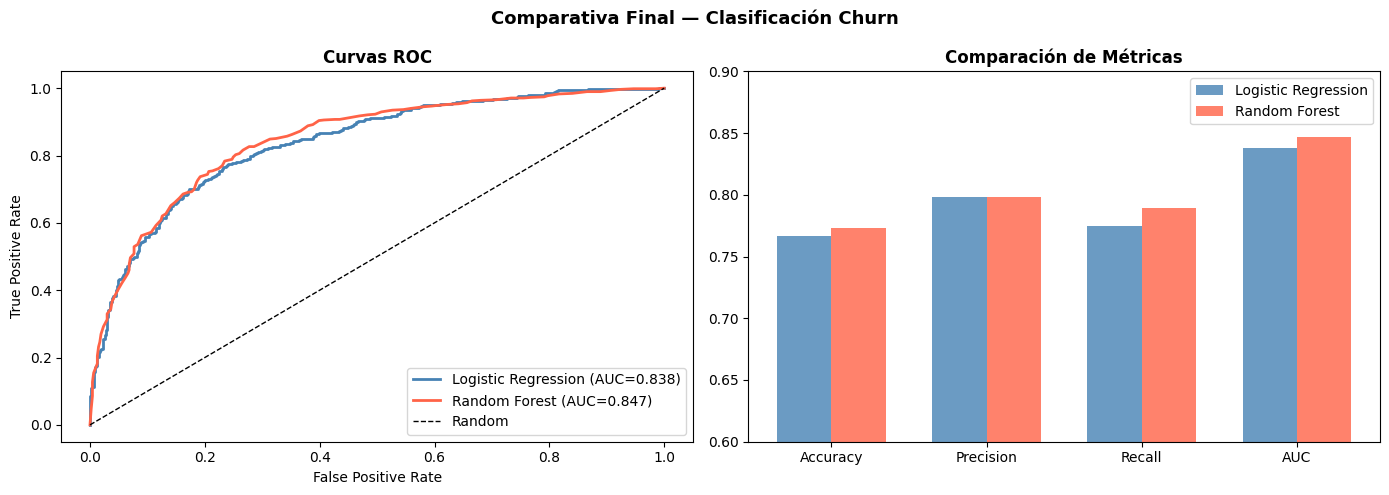

In [29]:
# COMPARACIÓN VISUAL DE MODELOS
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Curvas ROC ───────────────────────────────────────────────────────
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

axes[0].plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2, label=f'Logistic Regression (AUC=0.838)')
axes[0].plot(fpr_rf, tpr_rf, color='tomato', linewidth=2, label=f'Random Forest (AUC=0.847)')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curvas ROC', fontsize=12, fontweight='bold')
axes[0].legend()

# ── Comparación de métricas ──────────────────────────────────────────
metricas = ['Accuracy', 'Precision', 'Recall', 'AUC']
valores_lr = [0.767, 0.798, 0.775, 0.838]
valores_rf = [0.773, 0.798, 0.789, 0.847]

x = np.arange(len(metricas))
width = 0.35
axes[1].bar(x - width/2, valores_lr, width, label='Logistic Regression', color='steelblue', alpha=0.8)
axes[1].bar(x + width/2, valores_rf, width, label='Random Forest', color='tomato', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metricas)
axes[1].set_ylim(0.6, 0.9)
axes[1].set_title('Comparación de Métricas', fontsize=12, fontweight='bold')
axes[1].legend()

plt.suptitle('Comparativa Final — Clasificación Churn', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Comparativa de modelos — Clasificación Churn

- **Random Forest** supera a Logistic Regression en todas las métricas,
  especialmente en Recall (0.789 vs 0.775) y AUC (0.847 vs 0.838).
- Ambos modelos tienen la misma Precision (0.798), lo que indica que
  cuando predicen churn, aciertan en el mismo porcentaje.
- El mayor Recall de Random Forest es importante en este contexto:
  significa que detecta más clientes en riesgo real, minimizando los
  falsos negativos (clientes que hacen churn pero no fueron identificados).
- **Modelo seleccionado: Random Forest** por su mejor AUC y Recall.

## MODELO DE ENSAMBLE Y MEJORA

Se utilizará GridSearchCV sobre el Pipeline para optimizar los hiperparámetros del modelo **Random Forest**, aplicando validación cruzada de 5 folds y utilizando AUC como métrica de evaluación, con el objetivo de maximizar el rendimiento y la capacidad de generalización del modelo.

In [30]:
# OPTIMIZACIÓN DE HIPERPARÁMETROS — Random Forest

from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features":      ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor AUC (CV):", grid_rf.best_score_.round(4))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_split': 10, 'model__n_estimators': 300}
Mejor AUC (CV): 0.846


In [31]:
# EVALUACIÓN DEL MODELO OPTIMIZADO
best_rf = grid_rf.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:, 1]

print("── Random Forest Optimizado ──")
print(f"AUC:      {roc_auc_score(y_test, y_proba_best):.4f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"\n{classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn'])}")

── Random Forest Optimizado ──
AUC:      0.8580
Accuracy: 0.7945

              precision    recall  f1-score   support

    No Churn       0.77      0.77      0.77       469
       Churn       0.82      0.81      0.81       582

    accuracy                           0.79      1051
   macro avg       0.79      0.79      0.79      1051
weighted avg       0.79      0.79      0.79      1051



### Random Forest Optimizado

La optimización de hiperparámetros mediante GridSearchCV mejoró el modelo:

| Métrica  | Base  | Optimizado |
|----------|-------|------------|
| AUC      | 0.847 | 0.858      |
| Accuracy | 0.773 | 0.795      |
| F1 Churn | 0.79  | 0.81       |

Los mejores parámetros encontrados fueron:
- `max_depth=10` — limita la profundidad evitando sobreajuste
- `max_features='sqrt'` — usa raíz cuadrada de features en cada split
- `min_samples_split=10` — requiere al menos 10 muestras para dividir un nodo
- `n_estimators=300` — 300 árboles en el ensemble

REGRESION:



In [32]:
# PREPARACIÓN PARA REGRESIÓN
# Target: gasto futuro de clientes activos (los que NO hicieron churn)

df_eval['TotalPrice'] = df_eval['Quantity'] * df_eval['Price']

revenue_futuro = df_eval.groupby('Customer ID')['TotalPrice'].sum().reset_index()
revenue_futuro.columns = ['CustomerID', 'FutureRevenue']

# Unir con RFM (solo clientes activos)
rfm_reg = rfm[rfm['churn'] == 0].merge(revenue_futuro, on='CustomerID', how='left')
rfm_reg['FutureRevenue'] = rfm_reg['FutureRevenue'].fillna(0)

# Log-transform del target
rfm_reg['FutureRevenue_log'] = np.log1p(rfm_reg['FutureRevenue'])

print(f"Clientes para regresión: {len(rfm_reg):,}")
print(f"\nEstadísticas de FutureRevenue:")
print(rfm_reg['FutureRevenue'].describe().round(2))

Clientes para regresión: 2,344

Estadísticas de FutureRevenue:
count     2344.00
mean      1383.16
std       6121.31
min          3.35
25%        288.10
50%        555.28
75%       1128.04
max     168469.60
Name: FutureRevenue, dtype: float64


In [33]:
# MODELOS DE REGRESIÓN

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

X_reg = rfm_reg[feature_cols]
y_reg = rfm_reg['FutureRevenue_log']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)

modelos_reg = {
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge())
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(random_state=42))
    ])
}

print("Validación cruzada (5-fold) — RMSE:\n")
for nombre, modelo in modelos_reg.items():
    scores = cross_val_score(modelo, X_train_r, y_train_r,
                             cv=cv_reg, scoring='neg_root_mean_squared_error')
    rmse = -scores.mean()
    print(f"  {nombre:20s}  RMSE = {rmse:.4f} ± {(-scores).std():.4f}")

Validación cruzada (5-fold) — RMSE:

  Ridge                 RMSE = 0.8389 ± 0.0809
  Random Forest         RMSE = 0.8253 ± 0.0780


In [34]:
# EVALUACIÓN EN TEST SET

from sklearn.metrics import root_mean_squared_error

print("Métricas en Test Set:\n")
for nombre, modelo in modelos_reg.items():
    modelo.fit(X_train_r, y_train_r)
    y_pred_r = modelo.predict(X_test_r)
    rmse = root_mean_squared_error(y_test_r, y_pred_r)
    mae  = mean_absolute_error(y_test_r, y_pred_r)
    r2   = r2_score(y_test_r, y_pred_r)
    print(f"── {nombre} ──")
    print(f"   RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}\n")

Métricas en Test Set:

── Ridge ──
   RMSE: 0.8515 | MAE: 0.6375 | R²: 0.4687

── Random Forest ──
   RMSE: 0.8193 | MAE: 0.6110 | R²: 0.5082



In [35]:
# OPTIMIZACIÓN — Random Forest Regressor

from sklearn.model_selection import GridSearchCV

param_grid_reg = {
    "model__n_estimators":      [100, 200, 300],
    "model__max_depth":         [None, 5, 10],
    "model__min_samples_split": [2, 5, 10],
    "model__max_features":      ["sqrt", "log2"]
}

rf_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

grid_reg = GridSearchCV(
    estimator=rf_reg_pipeline,
    param_grid=param_grid_reg,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_reg.fit(X_train_r, y_train_r)

print("Mejores parámetros:", grid_reg.best_params_)
print("Mejor RMSE (CV):", -grid_reg.best_score_.round(4))

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 100}
Mejor RMSE (CV): 0.7989


In [36]:
# EVALUACIÓN DEL REGRESOR OPTIMIZADO
best_rf_reg = grid_reg.best_estimator_

y_pred_best_r = best_rf_reg.predict(X_test_r)
rmse_opt = root_mean_squared_error(y_test_r, y_pred_best_r)
mae_opt  = mean_absolute_error(y_test_r, y_pred_best_r)
r2_opt   = r2_score(y_test_r, y_pred_best_r)

print("── Random Forest Regressor Optimizado ──")
print(f"   RMSE: {rmse_opt:.4f} | MAE: {mae_opt:.4f} | R²: {r2_opt:.4f}")

# Comparativa
print("\n── Comparativa ──")
print(f"{'Modelo':35s}  RMSE    R²")
print(f"{'Ridge (base)':35s}  0.8515  0.4687")
print(f"{'Random Forest (base)':35s}  0.8193  0.5082")
print(f"{'Random Forest (optimizado)':35s}  {rmse_opt:.4f}  {r2_opt:.4f}")

── Random Forest Regressor Optimizado ──
   RMSE: 0.7902 | MAE: 0.5923 | R²: 0.5425

── Comparativa ──
Modelo                               RMSE    R²
Ridge (base)                         0.8515  0.4687
Random Forest (base)                 0.8193  0.5082
Random Forest (optimizado)           0.7902  0.5425


### Regresión — Predicción de Revenue Futuro

Se entrenaron dos modelos para predecir el gasto futuro de clientes activos
usando las mismas features RFM. El target es el logaritmo del revenue en el
período de evaluación (sep-dic 2011).

| Modelo                    | RMSE   | MAE    | R²     |
|---------------------------|--------|--------|--------|
| Ridge (base)              | 0.8515 | 0.6375 | 0.4687 |
| Random Forest (base)      | 0.8193 | 0.6110 | 0.5082 |
| Random Forest (optimizado)| 0.7902 | 0.5923 | 0.5425 |

**Modelo seleccionado: Random Forest optimizado** con el menor RMSE y mayor R².
El modelo explica el 54% de la varianza del gasto futuro usando solo variables RFM.

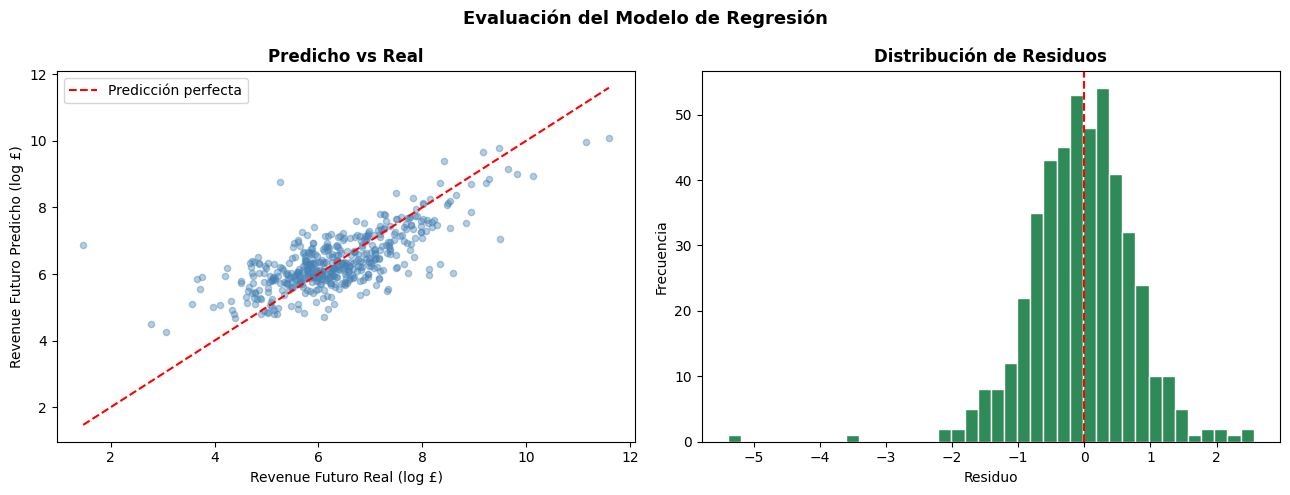

In [37]:
# GRÁFICO PREDICHO VS REAL — Regresión
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter predicho vs real
axes[0].scatter(y_test_r, y_pred_best_r, alpha=0.4, color='steelblue', s=20)
lims = [min(y_test_r.min(), y_pred_best_r.min()),
        max(y_test_r.max(), y_pred_best_r.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Revenue Futuro Real (log £)')
axes[0].set_ylabel('Revenue Futuro Predicho (log £)')
axes[0].set_title('Predicho vs Real', fontsize=12, fontweight='bold')
axes[0].legend()

# Distribución de residuos
residuos = y_test_r.values - y_pred_best_r
axes[1].hist(residuos, bins=40, color='seagreen', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribución de Residuos', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Residuo')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Evaluación del Modelo de Regresión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Evaluación visual del modelo de regresión

- **Predicho vs Real:** los puntos siguen de cerca la línea de predicción
  perfecta, especialmente en el rango medio (log £4-£9), lo que indica
  buena capacidad predictiva del modelo.
- **Residuos:** la distribución es aproximadamente normal y centrada en 0,
  lo que confirma que el modelo no tiene sesgo sistemático.
- Se observa mayor dispersión en valores extremos (clientes con gasto muy
  bajo o muy alto), lo cual es esperable dado que el modelo fue entrenado
  con variables RFM sin información de categorías de productos.

## INTERPRETABILIDAD DEL MODELO — SHAP

Una vez seleccionado el mejor modelo, se utiliza SHAP (SHapley Additive
Explanations) para interpretar las predicciones y entender qué variables
tienen mayor impacto en la predicción de churn.

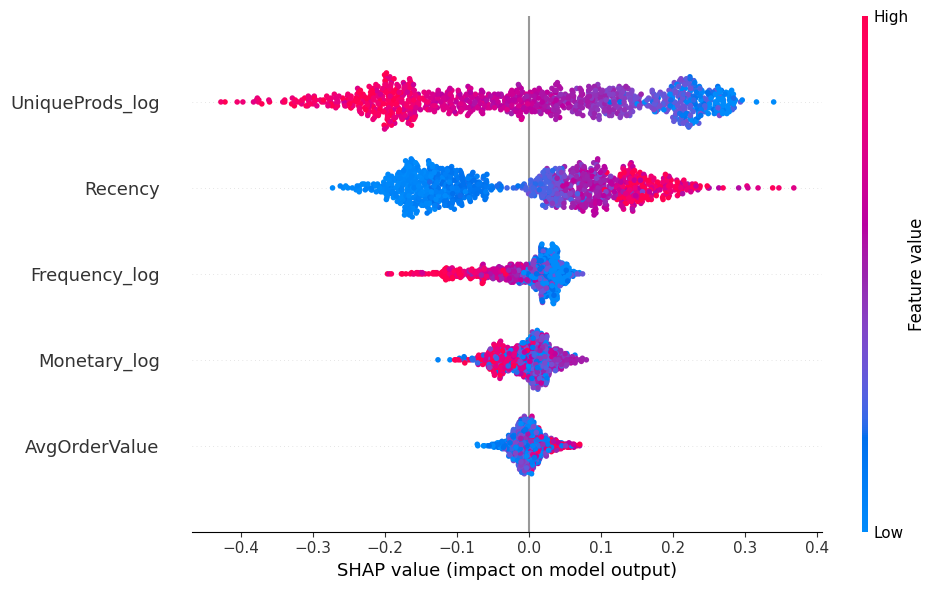

In [39]:
import shap

# SHAP — Clasificación
explainer = shap.TreeExplainer(best_rf.named_steps['model'])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values[:,:,1], X_test,
                  feature_names=feature_cols,
                  show=True, plot_size=(10, 6))

### Interpretación SHAP — Clasificación Churn

- **UniqueProds_log:** es la variable con mayor impacto. Clientes con
  pocos productos únicos comprados (azul) empujan fuertemente hacia churn
  (valores SHAP positivos). Clientes con alta variedad de productos (rojo)
  reducen la probabilidad de churn.

- **Recency:** valores bajos de recency (rojo, compras recientes) reducen
  el churn. Valores altos (azul, mucho tiempo sin comprar) aumentan
  fuertemente la probabilidad de churn.

- **Frequency_log y Monetary_log:** menor frecuencia y menor gasto
  (rojo) se asocian con mayor churn, aunque con menor impacto que
  las dos variables anteriores.

- **AvgOrderValue:** tiene el menor impacto, confirmando lo observado
  en la matriz de correlación.

**Conclusión:** la variedad de productos comprados y el tiempo desde
la última compra son los factores más determinantes para predecir el churn.

## CONCLUSIONES FINALES

### Clasificación — Predicción de Churn

- El modelo **Random Forest optimizado** fue el mejor clasificador con
  AUC=0.858 y Accuracy=0.795.
- La separación temporal (período de observación vs evaluación) fue clave
  para construir un target de churn sin data leakage.
- Las variables más importantes según SHAP fueron **UniqueProds** y
  **Recency**: clientes que compran poca variedad de productos y llevan
  mucho tiempo sin comprar tienen mayor probabilidad de churn.

### Regresión — Predicción de Revenue Futuro

- El modelo **Random Forest Regressor optimizado** obtuvo el mejor
  desempeño con RMSE=0.79 y R²=0.54.
- El modelo explica el 54% de la varianza del gasto futuro usando
  solo variables RFM, lo cual es razonable dado que no se cuenta con
  información de categorías de productos ni historial de navegación.
- Los residuos tienen distribución aproximadamente normal y centrada
  en 0, lo que indica ausencia de sesgo sistemático.

### Valor de negocio

Combinando ambos modelos se puede construir una matriz de priorización:

| Segmento | Churn | Revenue futuro | Acción recomendada |
|----------|-------|----------------|--------------------|
| A | Alto | Alto | Retención urgente — máxima prioridad |
| B | Alto | Bajo | Retención selectiva |
| C | Bajo | Alto | Upselling y fidelización |
| D | Bajo | Bajo | Monitoreo pasivo |

### Limitaciones y trabajo futuro
- El dataset está dominado por clientes del Reino Unido (~90%),
  el modelo podría no generalizar bien a otros mercados.
- Incorporar categorías de productos y comportamiento de navegación
  podría mejorar significativamente ambos modelos.
- Un modelo de series de tiempo podría capturar mejor la dinámica
  temporal de las compras.